# Análise Final Parametrizada

> Notebook parametrizado para executar a análise final permitindo escolher entre dois modos:
- incremental (início, fim e passo configuráveis, ex.: de 100 em 100);
- amostras (N pontos entre N_MIN e V_MAX, em escala linear ou logarítmica).

Instâncias suportadas: '10k' e '1m'.

---

In [8]:
# Imports necessários
from typing import Dict, List, Tuple
from collections import deque
from math import inf
import heapq
import os
import matplotlib.pyplot as plt
import numpy as np

## Configurações Iniciais

In [ ]:
# Configurações
ORIGEM = 0
SEED = 42

# Configuração do tamanho para visualização
n_exemplo = 10  # ← AJUSTE AQUI para mudar o tamanho dos grafos de exemplo

# Caminhos dos arquivos (apenas instâncias 10k e 1M)
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m  = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\1000000.txt'

# Instância ativa (para grafos esparsos): '10k' ou '1m' (case-insensitive)
INSTANCIA = '1m'

# Tipo de grafo: 'esparso' (lê arquivo) ou 'completo' (gerado)
TIPO_GRAFO = 'esparso'  # 'esparso' ou 'completo'

# Modo de geração de tamanhos: 'incremental' ou 'amostras'
MODO_TAMANHOS = 'incremental'

# Configurações do modo 'incremental'
INICIO_INCREMENTAL = None
FIM_INCREMENTAL    = None
PASSO_INCREMENTAL  = 1000

# Configurações do modo 'amostras'
N_AMOSTRAS = 50
ESCALA_AMOSTRAS = 'lin'  # 'lin' ou 'log'

# Parâmetros para grafo completo (ignorados se TIPO_GRAFO='esparso')
PESO_MIN = 1.0
PESO_MAX = 10.0
V_MAX_COMPLETO = 1000000
N_MIN_COMPLETO = 10

# Seleção de caminho e parâmetros por tipo de grafo
if TIPO_GRAFO.lower() == 'esparso':
    inst_norm = INSTANCIA.lower()
    if inst_norm == '10k':
        caminho = caminho_10k
        V_MAX = 10_000
        N_MIN = 10
        inst_suf = '10k'
    elif inst_norm == '1m':
        caminho = caminho_1m
        V_MAX = 1_000_000
        N_MIN = 1_000
        inst_suf = '1m'
    else:
        raise ValueError("INSTANCIA inválida. Use '10k' ou '1m'.")
else:  # grafo completo gerado
    caminho = None
    V_MAX = V_MAX_COMPLETO
    N_MIN = N_MIN_COMPLETO
    inst_suf = 'completo'

# Construção da lista de tamanhos conforme o modo
if MODO_TAMANHOS == 'incremental':
    inicio = INICIO_INCREMENTAL if INICIO_INCREMENTAL is not None else N_MIN
    fim    = FIM_INCREMENTAL    if FIM_INCREMENTAL    is not None else V_MAX
    inicio = max(2, int(inicio))
    fim    = int(fim)
    passo  = max(1, int(PASSO_INCREMENTAL))
    tamanhos = list(range(inicio, fim + 1, passo))
    if tamanhos and tamanhos[-1] != fim and fim > tamanhos[-1]:
        tamanhos.append(fim)
else:  # 'amostras'
    N_MIN = max(2, N_MIN)
    if ESCALA_AMOSTRAS == 'log':
        xs = np.logspace(np.log10(N_MIN), np.log10(V_MAX), num=max(2, N_AMOSTRAS))
    else:
        xs = np.linspace(N_MIN, V_MAX, num=max(2, N_AMOSTRAS))
    tamanhos = sorted({int(round(x)) for x in xs if N_MIN <= x <= V_MAX})

if TIPO_GRAFO.lower() == 'esparso':
    print('Verificando arquivos:')
    print(f"  10k: {'✓ Encontrado' if os.path.exists(caminho_10k) else '✗ Não encontrado'}")
    print(f"  1M : {'✓ Encontrado' if os.path.exists(caminho_1m) else '✗ Não encontrado'}")
else:
    print('Verificando arquivos: não aplicável para grafo completo (gerado)')

if TIPO_GRAFO.lower() == 'esparso':
    print(f"\nInstância ativa: {INSTANCIA} -> {caminho}")
else:
    print(f"\nInstância ativa: grafo completo (gerado)")
if MODO_TAMANHOS == 'incremental':
    print(f"Modo tamanhos: incremental (início={inicio:,}, fim={fim:,}, passo={passo:,})")
else:
    print(f"Modo tamanhos: amostras ({ESCALA_AMOSTRAS})")
print(f'Total de testes: {len(tamanhos)}')
print(f'Primeiros: {tamanhos[:10]}')
print(f'Últimos: {tamanhos[-10:]}')

Verificando arquivos:
  10k: ✓ Encontrado
  1M : ✓ Encontrado

Instância ativa: 1m -> D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\1000000.txt
Modo tamanhos: incremental (início=1,000, fim=1,000,000, passo=1,000)
Total de testes: 1000
Primeiros: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
Últimos: [991000, 992000, 993000, 994000, 995000, 996000, 997000, 998000, 999000, 1000000]


## Funções Auxiliares

In [10]:
def carregar_grafo_ewd(caminho: str, max_vertices: int = None):
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        if max_vertices is not None:
            V = min(V, max_vertices)
        adj = {i: [] for i in range(V)}
        num_arestas = 0
        for _ in range(E):
            linha = f.readline().strip()
            if not linha:
                break
            u, v, peso = linha.split()[:3]
            u, v = int(u), int(v)
            if u < V and v < V:
                adj[u].append((v, float(peso)))
                num_arestas += 1
    return adj, num_arestas
print('✓ Função de carregamento criada')

✓ Função de carregamento criada


In [11]:
# Gerador de grafo completo (lazy) — sem armazenar todas as arestas em memória
def _peso_uv(u: int, v: int, peso_min: float = 1.0, peso_max: float = 10.0) -> float:
    # Hash simples e determinístico para gerar pesos reprodutíveis
    h = (1103515245 * ((u << 16) ^ v) + 12345) & 0x7fffffff
    return peso_min + (h / 0x7fffffff) * (peso_max - peso_min)

class _Neighbors:
    def __init__(self, n: int, u: int, peso_min: float, peso_max: float):
        self.n = n
        self.u = u
        self.peso_min = peso_min
        self.peso_max = peso_max
    def __iter__(self):
        u = self.u; n = self.n; pmin = self.peso_min; pmax = self.peso_max
        for v in range(n):
            if v == u:
                continue
            yield (v, _peso_uv(u, v, pmin, pmax))

def gerar_grafo_completo_lazy(n: int, peso_min: float = 1.0, peso_max: float = 10.0):
    """
    Retorna uma estrutura de adjacência lazy para grafo completo direcionado com n vértices.
    adj[u] é iterável e produz (v, peso) para todo v != u sem materializar todas as arestas.
    """
    adj = [_Neighbors(n, u, peso_min, peso_max) for u in range(n)]
    num_arestas = n * (n - 1)  # dirigido, sem laços
    return adj, num_arestas

print('✓ Gerador de grafo completo (lazy) criado')

✓ Gerador de grafo completo (lazy) criado


## Visualização de Grafos (n=10)

VISUALIZAÇÃO DE GRAFOS (n=10)

1. Grafo Completo (n=10)

Grafo Completo (n=10)
  Vértices: 10
  Arestas: 90
  Densidade: 100.00%

Grafo Completo (n=10)
  Vértices: 10
  Arestas: 90
  Densidade: 100.00%


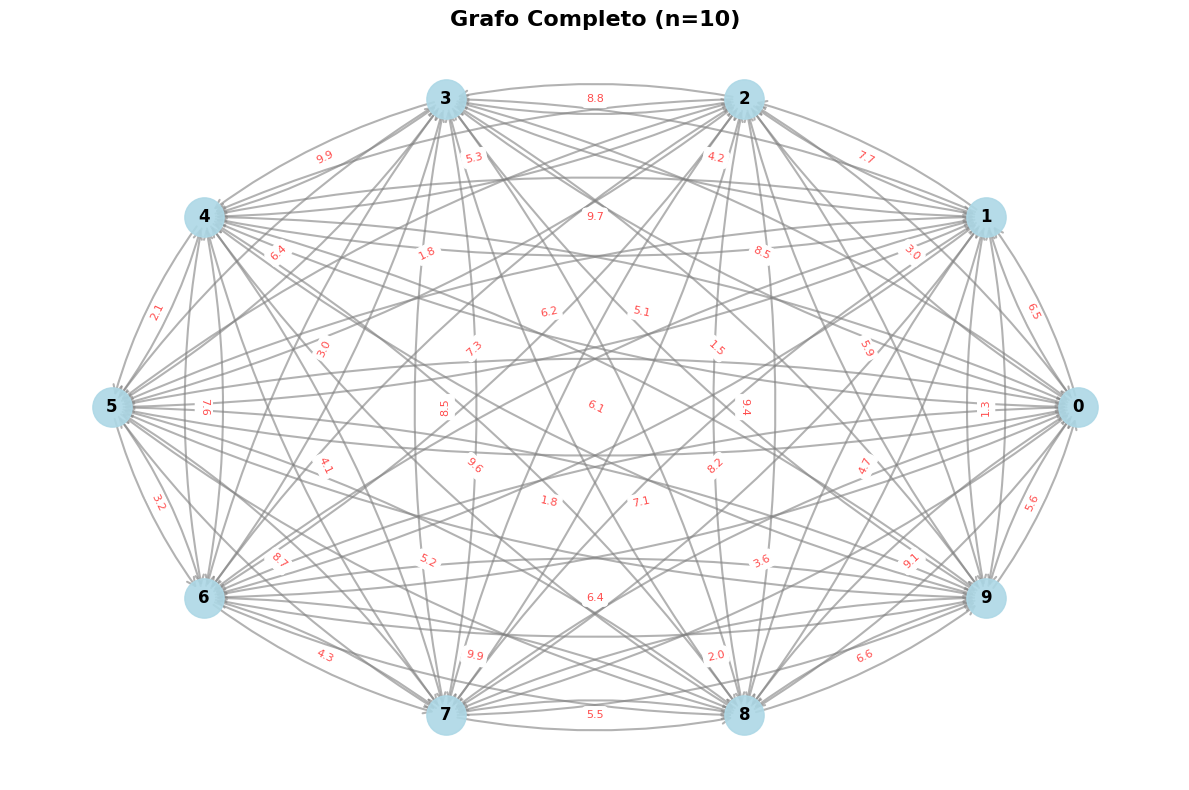


2. Grafo Esparso - Instância 1m
  ⚠ Apenas 0 vértices com arestas nos primeiros 100
  ⚠ Apenas 0 vértices com arestas nos primeiros 100

Grafo Esparso (subgrafo) - 1m
  Vértices: 10
  Arestas: 0
  Densidade: 0.00%

Grafo Esparso (subgrafo) - 1m
  Vértices: 10
  Arestas: 0
  Densidade: 0.00%


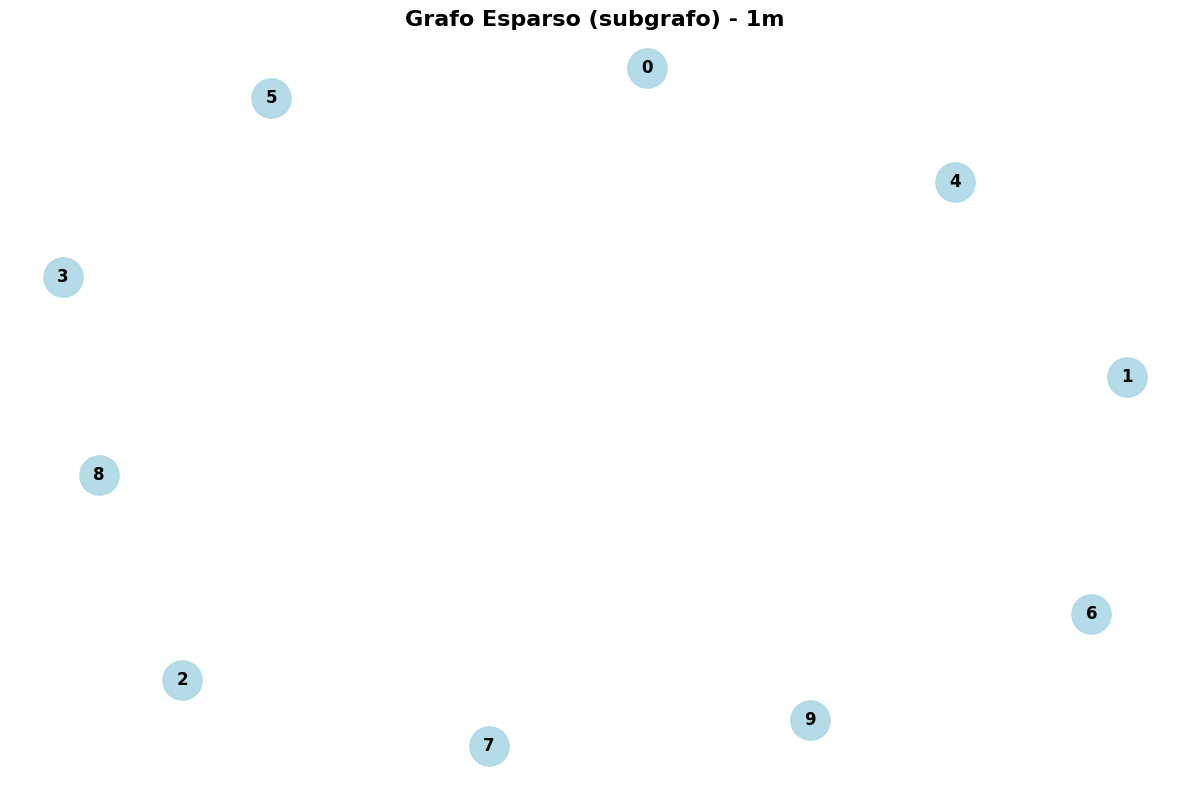


COMPARAÇÃO DE DENSIDADE
Grafo Completo:   90 arestas  (densidade: 100.00%)
Grafo Esparso:     0 arestas  (densidade: 0.00%)
Redução:         100.0%

✓ Visualizações salvas em: resultados/analise_esparsos/img/


In [ ]:
import networkx as nx

def visualizar_grafo(adj, titulo: str, n_max: int = None, pos_layout: str = 'spring'):
    """
    Visualiza grafo usando NetworkX.
    
    Args:
        adj: dicionário de adjacências {u: [(v1, peso1), (v2, peso2), ...]}
        titulo: título do gráfico
        n_max: número máximo de vértices (None = todos)
        pos_layout: 'spring', 'circular' ou 'kamada_kawai'
    
    Returns:
        G: grafo NetworkX
    """
    if n_max is None:
        n = len(adj)
    else:
        n = min(len(adj), n_max)
    
    # Criar grafo direcionado
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    
    # Adicionar arestas com pesos
    edge_labels = {}
    for u in range(n):
        for v, peso in adj[u]:
            if v < n:  # Garantir que está dentro do limite
                G.add_edge(u, v)
                edge_labels[(u, v)] = f'{peso:.1f}'
    
    # Layout
    if pos_layout == 'circular':
        pos = nx.circular_layout(G)
    elif pos_layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
    
    # Plotar
    plt.figure(figsize=(12, 8))
    
    # Desenhar nós
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=800, alpha=0.9)
    
    # Desenhar arestas
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          arrows=True, arrowsize=15, 
                          arrowstyle='->', connectionstyle='arc3,rad=0.1',
                          alpha=0.6, width=1.5)
    
    # Desenhar labels dos nós
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Desenhar labels das arestas (pesos)
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, 
                                 font_color='red', alpha=0.7)
    
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    # Informações
    print(f"\n{titulo}")
    print(f"  Vértices: {G.number_of_nodes()}")
    print(f"  Arestas: {G.number_of_edges()}")
    print(f"  Densidade: {nx.density(G):.2%}")
    
    return G



print("="*70)
print(f"VISUALIZAÇÃO DE GRAFOS (n={n_exemplo})")
print("="*70)

# 1. Grafo Completo
print(f"\n1. Grafo Completo (n={n_exemplo})")
grafo_completo_vis, _ = gerar_grafo_completo_lazy(n_exemplo, PESO_MIN, PESO_MAX)
G_completo = visualizar_grafo(grafo_completo_vis, 
                               titulo=f"Grafo Completo (n={n_exemplo})", 
                               pos_layout='circular')
os.makedirs('resultados/analise_esparsos/img', exist_ok=True)
plt.savefig(f'resultados/analise_esparsos/img/grafo_completo_n{n_exemplo}.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Grafo Esparso (se disponível)
if TIPO_GRAFO.lower() == 'esparso' and caminho and os.path.exists(caminho):
    print(f"\n2. Grafo Esparso - Instância {INSTANCIA}")
    
    # Carregar amostra maior para garantir arestas
    n_exemplo_esparso = max(100, n_exemplo * 10)  # Carregar mais vértices para ter arestas
    grafo_esparso_temp, _ = carregar_grafo_ewd(caminho, max_vertices=n_exemplo_esparso)
    
    # Encontrar vértices com mais conexões
    vertices_com_arestas = []
    for u in range(len(grafo_esparso_temp)):
        if len(grafo_esparso_temp[u]) > 0:
            vertices_com_arestas.append((u, len(grafo_esparso_temp[u])))
    
    if len(vertices_com_arestas) >= n_exemplo:
        # Pegar os n_exemplo vértices com mais arestas
        vertices_com_arestas.sort(key=lambda x: x[1], reverse=True)
        vertices_selecionados = sorted([v for v, _ in vertices_com_arestas[:n_exemplo]])
        
        # Criar subgrafo apenas com os vértices selecionados
        mapeamento = {v_orig: v_novo for v_novo, v_orig in enumerate(vertices_selecionados)}
        grafo_esparso_vis = {v_novo: [] for v_novo in range(len(vertices_selecionados))}
        
        for v_orig in vertices_selecionados:
            v_novo = mapeamento[v_orig]
            for destino, peso in grafo_esparso_temp[v_orig]:
                if destino in mapeamento:
                    grafo_esparso_vis[v_novo].append((mapeamento[destino], peso))
        
        print(f"  Selecionados {n_exemplo} vértices mais conectados (de 0 a {n_exemplo_esparso-1})")
        print(f"  Vértices originais: {vertices_selecionados}")
    else:
        # Não há vértices suficientes com arestas, usar os primeiros n_exemplo
        print(f"  ⚠ Apenas {len(vertices_com_arestas)} vértices com arestas nos primeiros {n_exemplo_esparso}")
        grafo_esparso_vis, _ = carregar_grafo_ewd(caminho, max_vertices=n_exemplo)
    
    G_esparso = visualizar_grafo(grafo_esparso_vis, 
                                 titulo=f"Grafo Esparso (subgrafo) - {INSTANCIA}", 
                                 pos_layout='spring')
    plt.savefig(f'resultados/analise_esparsos/img/grafo_esparso_{inst_suf}_n{n_exemplo}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Comparação
    print(f"\n{'='*70}")
    print("COMPARAÇÃO DE DENSIDADE")
    print(f"{'='*70}")
    print(f"Grafo Completo:  {G_completo.number_of_edges():3d} arestas  (densidade: {nx.density(G_completo):.2%})")
    print(f"Grafo Esparso:   {G_esparso.number_of_edges():3d} arestas  (densidade: {nx.density(G_esparso):.2%})")
    if G_completo.number_of_edges() > 0:
        reducao = (1 - G_esparso.number_of_edges() / G_completo.number_of_edges()) * 100
        print(f"Redução:         {reducao:.1f}%")
elif TIPO_GRAFO.lower() == 'completo':
    print("\n⚠ Grafo esparso não aplicável (TIPO_GRAFO='completo').")
    print("  Para comparar, defina TIPO_GRAFO='esparso' e execute novamente.")
else:
    print("\n⚠ Arquivo de grafo esparso não encontrado.")
    print("  Verifique os caminhos dos arquivos na configuração.")

print(f"\n✓ Visualizações salvas em: resultados/analise_esparsos/img/")


---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---
## Implementação

In [13]:
def dijkstra(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    n = len(adj)
    dist = [inf] * n
    parent = [-1] * n
    dist[origem] = 0
    heap = [(0, origem)]
    comparacoes = 0
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist[u]:
            continue
        for v, peso in adj[u]:
            comparacoes += 1
            nova = dist[u] + peso
            if nova < dist[v]:
                dist[v] = nova
                parent[v] = u
                heapq.heappush(heap, (nova, v))
    return dist, parent, comparacoes
print('✓ Dijkstra implementado')

✓ Dijkstra implementado


## Testes Incrementais com Dijkstra

In [14]:
resultados_dijkstra = {'tamanhos': [], 'arestas': [], 'comparacoes': [], 'alcancados': []}

# Executa mesmo sem arquivo quando TIPO_GRAFO='completo'
can_run = (TIPO_GRAFO.lower() == 'completo') or (caminho is not None and os.path.exists(caminho))
if can_run:
    print('='*70)
    print(f'PARTE 1: TESTES INCREMENTAIS - DIJKSTRA ({TIPO_GRAFO})')
    print('='*70)
    total = len(tamanhos)
    intervalo = max(1, total // 20)  # Imprime ~20 vezes durante execução
    for i, tam in enumerate(tamanhos, 1):
        if TIPO_GRAFO.lower() == 'completo':
            grafo, num_arestas = gerar_grafo_completo_lazy(tam, PESO_MIN, PESO_MAX)
        else:
            grafo, num_arestas = carregar_grafo_ewd(caminho, max_vertices=tam)
        dist, parent, comp = dijkstra(grafo, origem=ORIGEM)
        alc = sum(1 for d in dist if d != inf)
        resultados_dijkstra['tamanhos'].append(tam)
        resultados_dijkstra['arestas'].append(num_arestas)
        resultados_dijkstra['comparacoes'].append(comp)
        resultados_dijkstra['alcancados'].append(alc)
        if i % intervalo == 0 or i == 1 or i == total:
            perc = (i / total) * 100
            print(f'  [{i}/{total}] ({perc:.1f}%) n={tam:,}: {comp:,} comp, {alc:,} vértices')
    print('\n✓ Testes Dijkstra concluídos!')
else:
    print('✗ Arquivo não encontrado! Defina os caminhos corretamente ou use TIPO_GRAFO="completo".')

PARTE 1: TESTES INCREMENTAIS - DIJKSTRA (esparso)
  [1/1000] (0.1%) n=1,000: 0 comp, 1 vértices
  [1/1000] (0.1%) n=1,000: 0 comp, 1 vértices


KeyboardInterrupt: 

## Salvar Resultados - Dijkstra

In [ ]:
if resultados_dijkstra['tamanhos']:
    os.makedirs('resultados/analise_esparsos', exist_ok=True)
    with open(f'resultados/analise_esparsos/parte1_dijkstra_{inst_suf}.txt', 'w', encoding='utf-8') as f:
        f.write(f'PARTE 1 — ALGORITMO DE DIJKSTRA (Instância {INSTANCIA})\n')
        f.write('='*80 + '\n\n')
        f.write(f'{"Vértices":<12}{"Arestas":<12}{"Comparações":<16}{"Alcançados":<14}{"% Alcançados":<14}\n')
        f.write('-'*80 + '\n')
        for i in range(len(resultados_dijkstra['tamanhos'])):
            tam = resultados_dijkstra['tamanhos'][i]
            arestas = resultados_dijkstra['arestas'][i]
            comp = resultados_dijkstra['comparacoes'][i]
            alc = resultados_dijkstra['alcancados'][i]
            perc = (alc / tam * 100) if tam > 0 else 0
            f.write(f'{tam:<12,}{arestas:<12,}{comp:<16,}{alc:<14,}{perc:<14.2f}%\n')
    print(f'✓ Resultados salvos: resultados/analise_esparsos/parte1_dijkstra_{inst_suf}.txt')

## Gráficos - Dijkstra

In [ ]:
if resultados_dijkstra['tamanhos']:
    os.makedirs('resultados/analise_esparsos/img', exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['comparacoes'], marker='o', linewidth=2, markersize=4, color='steelblue')
    plt.xlabel('Número de vértices'); plt.ylabel('Número de comparações')
    plt.title('Dijkstra - Comparações vs Vértices')
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte1_dijkstra_comp_{inst_suf}.png', dpi=150); plt.show()
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['alcancados'], marker='o', linewidth=2, markersize=4, color='green')
    plt.xlabel('Número de vértices'); plt.ylabel('Vértices alcançados')
    plt.title('Dijkstra - Vértices Alcançados')
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte1_dijkstra_alcancados_{inst_suf}.png', dpi=150); plt.show()
else:
    print('✗ Resultados Dijkstra indisponíveis para gráficos')

✗ Resultados Dijkstra indisponíveis para gráficos


---
# PARTE 2 — HEURÍSTICA GULOSA
---
## Implementação

In [ ]:
def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    n = len(adj)
    dist = [inf] * n
    parent = [-1] * n
    dist[origem] = 0
    visited = {origem}
    fila = deque([origem])
    comparacoes = 0
    while fila:
        u = fila.popleft()
        melhor_v, melhor_custo = None, inf
        for v, peso in adj[u]:
            comparacoes += 1
            if v in visited:
                continue
            custo = dist[u] + peso
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo, melhor_v = custo, v
        if melhor_v is not None:
            dist[melhor_v] = melhor_custo
            parent[melhor_v] = u
            visited.add(melhor_v)
            fila.append(melhor_v)
    return dist, parent, comparacoes
print('✓ Heurística Gulosa implementada')

✓ Heurística Gulosa implementada


## Testes Incrementais com Heurística Gulosa

In [ ]:
resultados_gulosa = {'tamanhos': [], 'arestas': [], 'comparacoes': [], 'alcancados': []}

# Executa mesmo sem arquivo quando TIPO_GRAFO='completo'
can_run = (TIPO_GRAFO.lower() == 'completo') or (caminho is not None and os.path.exists(caminho))
if can_run:
    print('='*70)
    print(f'PARTE 2: TESTES INCREMENTAIS - HEURÍSTICA GULOSA ({TIPO_GRAFO})')
    print('='*70)
    total = len(tamanhos)
    intervalo = max(1, total // 20)  # Imprime ~20 vezes durante execução
    for i, tam in enumerate(tamanhos, 1):
        if TIPO_GRAFO.lower() == 'completo':
            grafo, num_arestas = gerar_grafo_completo_lazy(tam, PESO_MIN, PESO_MAX)
        else:
            grafo, num_arestas = carregar_grafo_ewd(caminho, max_vertices=tam)
        dist, parent, comp = heuristica_gulosa(grafo, origem=ORIGEM)
        alc = sum(1 for d in dist if d != inf)
        resultados_gulosa['tamanhos'].append(tam)
        resultados_gulosa['arestas'].append(num_arestas)
        resultados_gulosa['comparacoes'].append(comp)
        resultados_gulosa['alcancados'].append(alc)
        if i % intervalo == 0 or i == 1 or i == total:
            perc = (i / total) * 100
            print(f'  [{i}/{total}] ({perc:.1f}%) n={tam:,}: {comp:,} comp, {alc:,} vértices')
    print('\n✓ Testes Gulosa concluídos!')
else:
    print('✗ Arquivo não encontrado! Defina os caminhos corretamente ou use TIPO_GRAFO="completo".')

✗ Arquivo não encontrado! Defina os caminhos corretamente ou use TIPO_GRAFO="completo".


## Salvar Resultados - Heurística Gulosa

In [ ]:
if resultados_gulosa['tamanhos']:
    os.makedirs('resultados/analise_esparsos', exist_ok=True)
    with open(f'resultados/analise_esparsos/parte2_gulosa_{inst_suf}.txt', 'w', encoding='utf-8') as f:
        f.write(f'PARTE 2 — HEURÍSTICA GULOSA (Instância {INSTANCIA})\n')
        f.write('='*80 + '\n\n')
        f.write(f'{"Vértices":<12}{"Arestas":<12}{"Comparações":<16}{"Alcançados":<14}{"% Alcançados":<14}\n')
        f.write('-'*80 + '\n')
        for i in range(len(resultados_gulosa['tamanhos'])):
            tam = resultados_gulosa['tamanhos'][i]
            arestas = resultados_gulosa['arestas'][i]
            comp = resultados_gulosa['comparacoes'][i]
            alc = resultados_gulosa['alcancados'][i]
            perc = (alc / tam * 100) if tam > 0 else 0
            f.write(f'{tam:<12,}{arestas:<12,}{comp:<16,}{alc:<14,}{perc:<14.2f}%\n')
    print(f'✓ Resultados salvos: resultados/analise_esparsos/parte2_gulosa_{inst_suf}.txt')

## Gráficos - Heurística Gulosa

In [ ]:
if resultados_gulosa['tamanhos']:
    os.makedirs('resultados/analise_esparsos/img', exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['comparacoes'], marker='s', linewidth=2, markersize=4, color='orange')
    plt.xlabel('Número de vértices'); plt.ylabel('Número de comparações')
    plt.title('Gulosa - Comparações vs Vértices')
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte2_gulosa_comp_{inst_suf}.png', dpi=150); plt.show()
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['alcancados'], marker='s', linewidth=2, markersize=4, color='red')
    plt.xlabel('Número de vértices'); plt.ylabel('Vértices alcançados')
    plt.title('Gulosa - Vértices Alcançados')
    plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte2_gulosa_alcancados_{inst_suf}.png', dpi=150); plt.show()
else:
    print('✗ Resultados Gulosa indisponíveis para gráficos')

✗ Resultados Gulosa indisponíveis para gráficos


---
# COMPARAÇÃO ENTRE OS ALGORITMOS
---
## Tabela + Gráficos

In [ ]:
if resultados_dijkstra['tamanhos'] and resultados_gulosa['tamanhos']:
    with open(f'resultados/analise_esparsos/comparacao_{inst_suf}.txt', 'w', encoding='utf-8') as f:
        f.write(f'COMPARAÇÃO: DIJKSTRA vs HEURÍSTICA GULOSA (Instância {INSTANCIA})\n')
        f.write('='*120 + '\n\n')
        f.write(f'{"Vértices":<10}{"Arestas":<10}{"Dij Comp":<14}{"Dij Alc":<12}{"Gul Comp":<14}{"Gul Alc":<12}{"Red Comp%":<12}{"Perda Alc%":<14}\n')
        f.write('-'*120 + '\n')
        for i in range(len(resultados_dijkstra['tamanhos'])):
            tam = resultados_dijkstra['tamanhos'][i]
            arestas = resultados_dijkstra['arestas'][i]
            d_comp = resultados_dijkstra['comparacoes'][i]
            d_alc = resultados_dijkstra['alcancados'][i]
            g_comp = resultados_gulosa['comparacoes'][i]
            g_alc = resultados_gulosa['alcancados'][i]
            red_comp = (1 - g_comp/d_comp)*100 if d_comp > 0 else 0
            perda_alc = (1 - g_alc/d_alc)*100 if d_alc > 0 else 0
            f.write(f'{tam:<10,}{arestas:<10,}{d_comp:<14,}{d_alc:<12,}{g_comp:<14,}{g_alc:<12,}{red_comp:<12.2f}%{perda_alc:<14.2f}%\n')
    os.makedirs('resultados/analise_esparsos/img', exist_ok=True)
    # Comparações linear
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['comparacoes'], marker='o', linewidth=2, markersize=4, color='steelblue', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['comparacoes'], marker='s', linewidth=2, markersize=4, color='orange', label='Gulosa')
    plt.xlabel('Número de vértices'); plt.ylabel('Comparações'); plt.title('Comparações: Dijkstra vs Gulosa'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_comp_{inst_suf}.png', dpi=150); plt.show()
    # Comparações (y-log)
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['comparacoes'], marker='o', linewidth=2, markersize=4, color='steelblue', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['comparacoes'], marker='s', linewidth=2, markersize=4, color='orange', label='Gulosa')
    plt.yscale('log')
    plt.xlabel('Número de vértices'); plt.ylabel('Comparações (log)'); plt.title('Comparações (y-log): Dijkstra vs Gulosa'); plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_comp_log_{inst_suf}.png', dpi=150); plt.show()
    # Alcançados (linear)
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['alcancados'], marker='o', linewidth=2, markersize=4, color='green', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['alcancados'], marker='s', linewidth=2, markersize=4, color='red', label='Gulosa')
    plt.xlabel('Número de vértices'); plt.ylabel('Vértices alcançados'); plt.title('Vértices Alcançados: Dijkstra vs Gulosa'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_alcancados_{inst_suf}.png', dpi=150); plt.show()
    # Alcançados (y-log)
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['alcancados'], marker='o', linewidth=2, markersize=4, color='green', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['alcancados'], marker='s', linewidth=2, markersize=4, color='red', label='Gulosa')
    plt.yscale('log')
    plt.xlabel('Número de vértices'); plt.ylabel('Vértices alcançados (log)'); plt.title('Vértices Alcançados (y-log): Dijkstra vs Gulosa'); plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_alcancados_log_{inst_suf}.png', dpi=150); plt.show()
    # Redução de comparações
    reducao_comp = [(1 - g/d)*100 if d > 0 else 0 for g,d in zip(resultados_gulosa['comparacoes'], resultados_dijkstra['comparacoes'])]
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], reducao_comp, marker='o', linewidth=2, markersize=4, color='purple')
    plt.xlabel('Número de vértices'); plt.ylabel('Redução de comparações (%)'); plt.title('Redução de Comparações pela Gulosa'); plt.grid(True, linestyle='--', alpha=0.6); plt.axhline(y=0, color='black', linestyle='-', alpha=0.3); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/reducao_comparacoes_{inst_suf}.png', dpi=150); plt.show()
    # Taxa de alcance (Gulosa vs Dijkstra)
    taxa_alc = [(g/d)*100 if d > 0 else 0 for g,d in zip(resultados_gulosa['alcancados'], resultados_dijkstra['alcancados'])]
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], taxa_alc, marker='o', linewidth=2, markersize=4, color='crimson')
    plt.xlabel('Número de vértices'); plt.ylabel('% de vértices alcançados'); plt.title('Taxa de Alcance da Gulosa'); plt.grid(True, linestyle='--', alpha=0.6); plt.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100% (ideal)'); plt.legend(); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/taxa_alcance_gulosa_{inst_suf}.png', dpi=150); plt.show()
    # Taxa de alcance absoluta (%) — Dijkstra e Gulosa
    perc_dij = [(d/t)*100 if t > 0 else 0 for d,t in zip(resultados_dijkstra['alcancados'], resultados_dijkstra['tamanhos'])]
    perc_gul = [(g/t)*100 if t > 0 else 0 for g,t in zip(resultados_gulosa['alcancados'], resultados_gulosa['tamanhos'])]
    plt.figure(figsize=(8,5))
    plt.plot(resultados_dijkstra['tamanhos'], perc_dij, marker='o', linewidth=2, markersize=4, color='green', label='Dijkstra (%)')
    plt.plot(resultados_gulosa['tamanhos'], perc_gul, marker='s', linewidth=2, markersize=4, color='red', label='Gulosa (%)')
    plt.xlabel('Número de vértices'); plt.ylabel('% de vértices alcançados (absoluto)'); plt.title('Taxa de Alcance Absoluta: Dijkstra vs Gulosa'); plt.grid(True, linestyle='--', alpha=0.6); plt.axhline(y=100, color='black', linestyle=':', alpha=0.4); plt.legend(); plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/taxa_alcance_absoluta_{inst_suf}.png', dpi=150); plt.show()
else:
    print('✗ Resultados insuficientes para comparação')

✗ Resultados insuficientes para comparação


In [ ]:
# Simulação (n=10) — Grafo Completo vs Grafo Esparso (simulado)
import numpy as np


def gerar_grafo_esparso_simulado(n: int,
                                 p: float = 0.25,
                                 peso_min: float = 1.0,
                                 peso_max: float = 10.0,
                                 seed: int = 123):
    """
    Gera um grafo esparso DIRECIONADO com n vértices, adicionando cada aresta (u->v)
    com probabilidade p. Garante ao menos 1 aresta de saída por vértice.

    Parâmetros são locais (não usam variáveis globais do notebook).

    Retorna:
      - adj: dicionário {u: [(v, peso), ...]}
      - num_arestas: total de arestas geradas
    """
    rng = np.random.default_rng(seed)
    adj = {u: [] for u in range(n)}

    for u in range(n):
        for v in range(n):
            if v == u:
                continue
            if rng.random() < p:
                w = float(rng.uniform(peso_min, peso_max))
                adj[u].append((v, w))
        # garante pelo menos 1 saída
        if not adj[u]:
            candidatos = [x for x in range(n) if x != u]
            v = int(rng.choice(candidatos))
            w = float(rng.uniform(peso_min, peso_max))
            adj[u].append((v, w))

    num_arestas = sum(len(adj[u]) for u in range(n))
    return adj, num_arestas


# Parâmetros da simulação (definidos localmente)
N_SIM = 10
P_ESPARSO = 0.25  # probabilidade de aresta no esparso
PESO_MIN_SIM = 1.0
PESO_MAX_SIM = 10.0
SEED_SIM = 123

print("="*70)
print("SIMULAÇÃO (n=10) — COMPLETO vs ESPARSO (simulado)")
print("="*70)

# 1) Grafo completo (lazy) — parâmetros explícitos
grafo_completo_sim, _ = gerar_grafo_completo_lazy(N_SIM, PESO_MIN_SIM, PESO_MAX_SIM)
Gc = visualizar_grafo(grafo_completo_sim,
                      titulo=f"[Sim] Grafo Completo (n={N_SIM})",
                      n_max=N_SIM,
                      pos_layout='circular')
os.makedirs('resultados/analise_esparsos/img', exist_ok=True)
plt.savefig(f'resultados/analise_esparsos/img/grafo_completo_sim_n{N_SIM}.png', dpi=150, bbox_inches='tight')
plt.show()

# 2) Grafo esparso (simulado) — totalmente desacoplado do restante do notebook
grafo_esparso_sim, num_e = gerar_grafo_esparso_simulado(N_SIM,
                                                        p=P_ESPARSO,
                                                        peso_min=PESO_MIN_SIM,
                                                        peso_max=PESO_MAX_SIM,
                                                        seed=SEED_SIM)
Ge = visualizar_grafo(grafo_esparso_sim,
                      titulo=f"[Sim] Grafo Esparso (n={N_SIM}, p={P_ESPARSO})",
                      n_max=N_SIM,
                      pos_layout='spring')
plt.savefig(f'resultados/analise_esparsos/img/grafo_esparso_sim_n{N_SIM}.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nArquivos gerados:")
print(f"  - resultados/analise_esparsos/img/grafo_completo_sim_n{N_SIM}.png")
print(f"  - resultados/analise_esparsos/img/grafo_esparso_sim_n{N_SIM}.png")